# Notebook 3: Robyn — Meta's MMM
## Dissertation: Integrating User Experience Metrics into Marketing Mix Modelling
### A Comparative Analysis of Bayesian Frameworks for Holistic Marketing Attribution

**Framework:** Robyn (Meta / Facebook)
**Approach:** Ridge regression + Nevergrad multi-objective optimisation
**Dataset:** Synthetic weekly data — 5 media channels + 5 UX metrics (104 weeks)

---
### Notebook Structure
1. Setup & Data Loading
2. Exploratory Data Analysis
3. Robyn Input Configuration
4. Model Training (Multi-trial optimisation)
5. Pareto-Optimal Model Selection
6. Media Contribution Decomposition
7. UX Metric Contribution Analysis
8. Budget Optimisation
9. Export One-Pager & Results


## 1. Setup & Data Loading

In [1]:
.libPaths(c('~/R/library', .libPaths()))

# Point reticulate to conda Python BEFORE loading Robyn
Sys.setenv(RETICULATE_PYTHON = '/home/terrymh/miniconda3/bin/python3')

suppressPackageStartupMessages({
  library(reticulate)
  library(Robyn)
  library(dplyr)
  library(ggplot2)
  library(data.table)
  library(RPostgres)
  library(DBI)
})

# Verify nevergrad is accessible
ng <- reticulate::import('nevergrad')
cat('Nevergrad: imported successfully\n')

OUTPUT_PATH  <- '../outputs/'
FIGURES_PATH <- '../outputs/figures/'

media_cols <- c('tv_spend', 'digital_spend', 'social_spend', 'search_spend', 'radio_spend')
ux_cols    <- c('bounce_rate', 'session_duration', 'pages_per_session', 'nps_score', 'conversion_rate')

# PostgreSQL connection
con <- dbConnect(
  RPostgres::Postgres(),
  host     = 'localhost',
  port     = 5432,
  dbname   = 'dissertation',
  user     = 'admin',
  password = 'admin123'
)

cat('Robyn version:', as.character(packageVersion('Robyn')), '\n')
cat('PostgreSQL   : connected\n')


Nevergrad: imported successfully
Robyn version: 3.12.1 
PostgreSQL   : connected


In [2]:
# Load cleaned data from dbt staging table
# Cast date as TEXT so R receives a parseable string
df <- dbGetQuery(con,
  "SELECT CAST(date AS TEXT) as date, sales,
          tv_spend, digital_spend, social_spend, search_spend,
          radio_spend, bounce_rate, session_duration, pages_per_session,
          nps_score, conversion_rate
   FROM public.stg_mmm_weekly_data ORDER BY date")

df$date <- as.Date(df$date)

cat('Shape:', nrow(df), 'x', ncol(df), '\n')
cat('Date class:', class(df$date), '\n')
cat('Date range:', as.character(min(df$date)), 'to', as.character(max(df$date)), '\n')
cat('Columns:', paste(names(df), collapse=', '), '\n')
head(df)


Shape: 104 x 12 
Date class: Date 
Date range: 2022-01-02 to 2023-12-24 
Columns: date, sales, tv_spend, digital_spend, social_spend, search_spend, radio_spend, bounce_rate, session_duration, pages_per_session, nps_score, conversion_rate 


,date,sales,tv_spend,digital_spend,social_spend,search_spend,radio_spend,bounce_rate,session_duration,pages_per_session,nps_score,conversion_rate
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2022-01-02,69178.37,17814.09,7628.19,2937.19,2592.92,979.01,0.6231,207.26,5.10,27.1,0.0268
2,2022-01-09,71005.51,12235.97,9790.38,3285.76,4998.84,675.38,0.4713,156.82,4.27,48.3,0.0100
3,2022-01-16,73280.02,11511.40,8063.87,2642.19,1540.99,511.75,0.4179,223.56,3.75,33.2,0.0343
4,2022-01-23,68860.09,11511.52,17442.55,4237.95,3672.71,1391.25,0.4930,184.58,3.14,37.8,0.0343
5,2022-01-30,73977.26,30830.70,11473.26,1621.16,6459.56,396.86,0.4538,218.01,3.55,47.4,0.0257
6,2022-02-06,77751.71,20632.26,4492.67,3060.33,3792.27,2668.71,0.5467,172.08,3.66,56.7,0.0363


## 2. Exploratory Data Analysis

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


Saved: 09_robyn_sales_trend.png


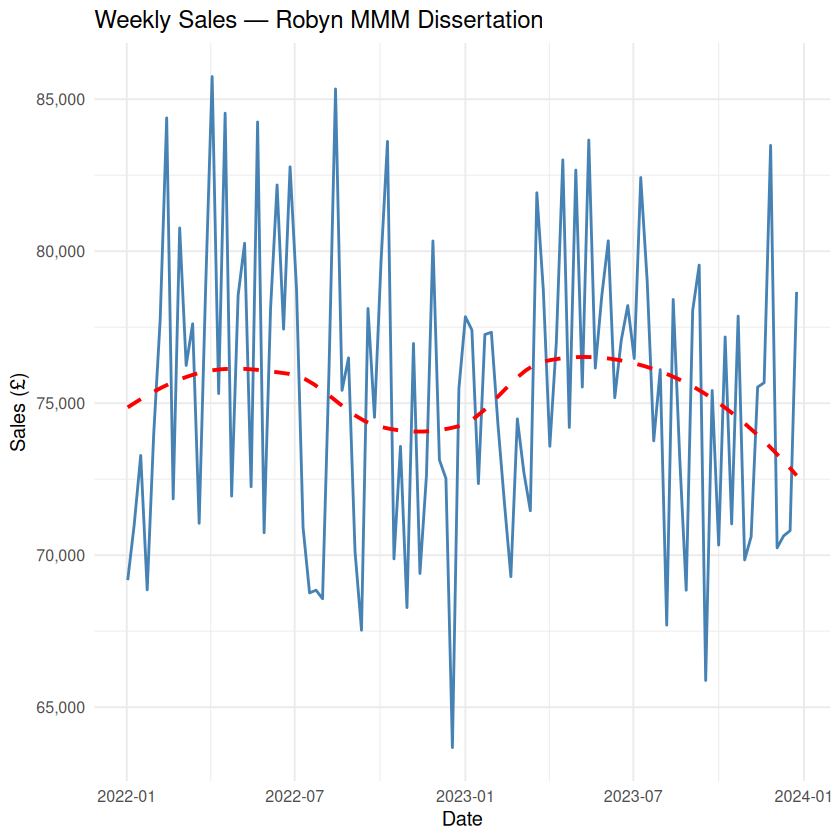

In [3]:
# Sales trend plot
p1 <- ggplot(df, aes(x=date, y=sales)) +
  geom_line(color='steelblue', linewidth=0.8) +
  geom_smooth(method='loess', color='red', linetype='dashed', se=FALSE) +
  scale_y_continuous(labels=scales::comma) +
  labs(title='Weekly Sales — Robyn MMM Dissertation',
       x='Date', y='Sales (£)') +
  theme_minimal(base_size=12)

print(p1)
ggsave(paste0(FIGURES_PATH, '09_robyn_sales_trend.png'), p1, width=12, height=5, dpi=150)
cat("Saved: 09_robyn_sales_trend.png\n")


Saved: 10_robyn_media_spend.png


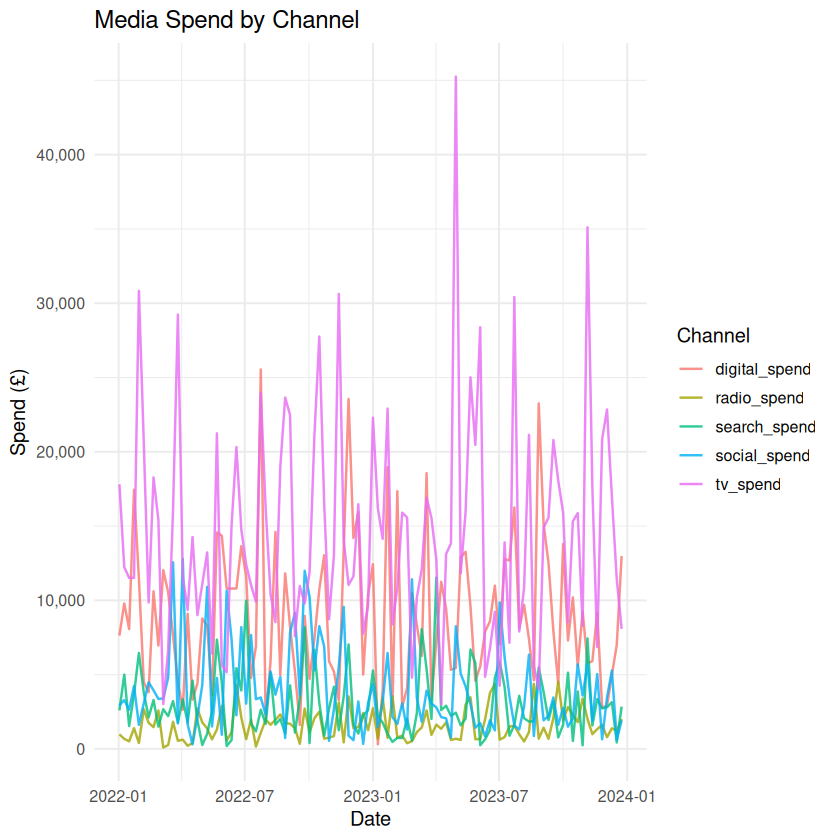

In [4]:
# Media spend over time
library(tidyr)

df_media <- df %>%
  select(date, tv_spend, digital_spend, social_spend, search_spend, radio_spend) %>%
  pivot_longer(-date, names_to='channel', values_to='spend')

p2 <- ggplot(df_media, aes(x=date, y=spend, color=channel)) +
  geom_line(linewidth=0.7, alpha=0.8) +
  scale_y_continuous(labels=scales::comma) +
  labs(title='Media Spend by Channel', x='Date', y='Spend (£)', color='Channel') +
  theme_minimal(base_size=12)

print(p2)
ggsave(paste0(FIGURES_PATH, '10_robyn_media_spend.png'), p2, width=12, height=5, dpi=150)
cat("Saved: 10_robyn_media_spend.png\n")


Saved: 11_robyn_ux_metrics.png


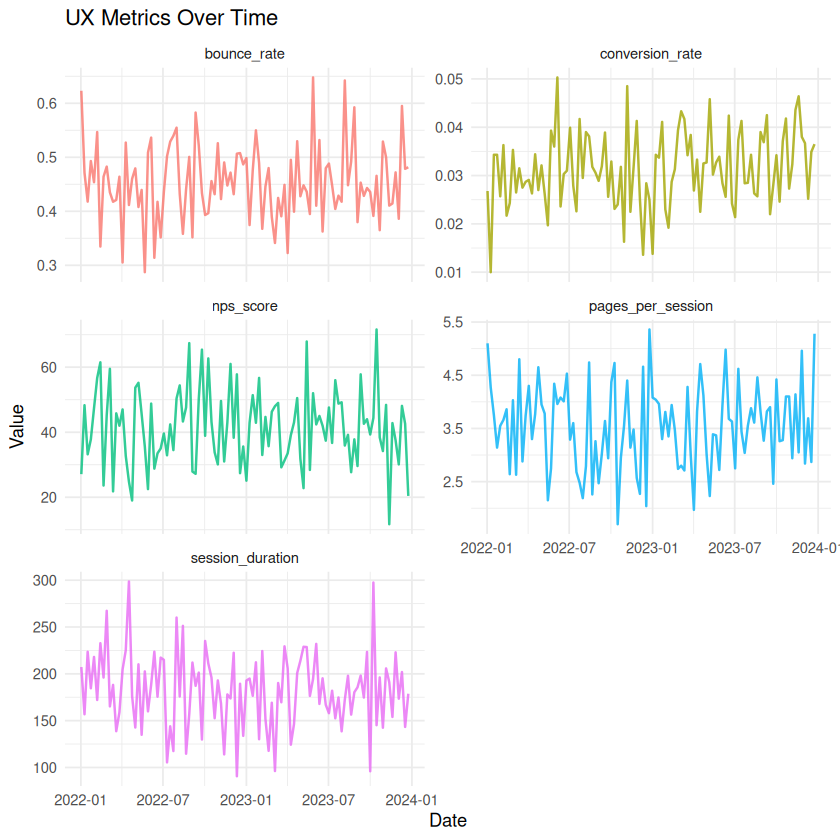

In [5]:
# UX metrics over time
df_ux <- df %>%
  select(date, bounce_rate, session_duration, pages_per_session, nps_score, conversion_rate) %>%
  pivot_longer(-date, names_to='metric', values_to='value')

p3 <- ggplot(df_ux, aes(x=date, y=value, color=metric)) +
  geom_line(linewidth=0.7, alpha=0.8) +
  facet_wrap(~metric, scales='free_y', ncol=2) +
  labs(title='UX Metrics Over Time', x='Date', y='Value') +
  theme_minimal(base_size=11) +
  theme(legend.position='none')

print(p3)
ggsave(paste0(FIGURES_PATH, '11_robyn_ux_metrics.png'), p3, width=12, height=8, dpi=150)
cat("Saved: 11_robyn_ux_metrics.png\n")


## 3. Robyn Input Configuration

In [6]:
# Load Prophet holidays data (built into Robyn)
data('dt_prophet_holidays')
cat('Prophet holidays loaded:', nrow(dt_prophet_holidays), 'rows\n')
cat('Countries available:', length(unique(dt_prophet_holidays$country)), '\n')


Prophet holidays loaded: 87651 rows
Countries available: 123 


In [7]:
InputCollect <- robyn_inputs(
  dt_input        = df,
  dt_holidays     = dt_prophet_holidays,
  date_var        = "date",
  dep_var         = "sales",
  dep_var_type    = "revenue",

  # Media channels
  paid_media_spends = c("tv_spend", "digital_spend", "social_spend",
                        "search_spend", "radio_spend"),
  paid_media_vars   = c("tv_spend", "digital_spend", "social_spend",
                        "search_spend", "radio_spend"),

  # UX metrics
  organic_vars  = c("nps_score"),
  context_vars  = c("bounce_rate", "session_duration",
                    "pages_per_session", "conversion_rate"),

  # Prophet
  prophet_vars    = c("trend", "season", "weekday", "holiday"),
  prophet_country = "GB",

  # Adstock
  adstock = "geometric",

  hyperparameters = list(
    tv_spend_alphas      = c(0.5, 3), tv_spend_gammas = c(0.3, 1), tv_spend_thetas = c(0.3, 0.8),
    digital_spend_alphas = c(0.5, 3), digital_spend_gammas = c(0.3, 1), digital_spend_thetas = c(0.1, 0.4),
    social_spend_alphas  = c(0.5, 3), social_spend_gammas = c(0.3, 1), social_spend_thetas = c(0.1, 0.4),
    search_spend_alphas  = c(0.5, 3), search_spend_gammas = c(0.3, 1), search_spend_thetas = c(0.1, 0.3),
    radio_spend_alphas   = c(0.5, 3), radio_spend_gammas = c(0.3, 1), radio_spend_thetas = c(0.3, 0.7),
    nps_score_alphas     = c(0.5, 3), nps_score_gammas = c(0.3, 1), nps_score_thetas = c(0.1, 0.5),
    train_size           = c(0.5, 0.8)
  )
)

print(InputCollect)


Warning message in check_datadim(dt_input, all_ind_vars, rel = 10):
“There are 14 independent variables & 104 data points. We recommend row:column ratio of 10 to 1”
>> Running feature engineering...



Total Observations: 104 (weeks)
Input Table Columns (12):
  Date: date
  Dependent: sales [revenue]
  Paid Media: tv_spend, digital_spend, social_spend, search_spend, radio_spend
  Paid Media Spend: tv_spend, digital_spend, social_spend, search_spend, radio_spend
  Context: bounce_rate, session_duration, pages_per_session, conversion_rate
  Organic: nps_score
  Prophet (Auto-generated): trend, season, weekday, holiday on GB
  Unused variables: None

Date Range: 2022-01-02:2023-12-24
Model Window: 2022-01-02:2023-12-30 (104 weeks)
With Calibration: FALSE
Custom parameters: None

Adstock: geometric
Hyper-parameters ranges:
  tv_spend_alphas: [0.5, 3]
  tv_spend_gammas: [0.3, 1]
  tv_spend_thetas: [0.3, 0.8]
  digital_spend_alphas: [0.5, 3]
  digital_spend_gammas: [0.3, 1]
  digital_spend_thetas: [0.1, 0.4]
  social_spend_alphas: [0.5, 3]
  social_spend_gammas: [0.3, 1]
  social_spend_thetas: [0.1, 0.4]
  search_spend_alphas: [0.5, 3]
  search_spend_gammas: [0.3, 1]
  search_spend_thetas:

## 4. Model Training

In [8]:
# Run Robyn optimisation
# trials=3, iterations=500 for dissertation
# Use trials=1, iterations=100 for quick test
OutputCollect <- robyn_run(
  InputCollect  = InputCollect,
  cores         = 4,
  iterations    = 300,
  trials        = 1,
  ts_validation = TRUE,
  add_penalty_factor = FALSE
)

print(OutputCollect)


Warning message in check_iteration(InputCollect$calibration_input, iterations, trials, :
“We recommend to run at least 2000 iterations per trial and 5 trials to build initial model”
Input data has 104 weeks in total: 2022-01-02 to 2023-12-30

Initial model is built on rolling window of 104 week: 2022-01-02 to 2023-12-30

Time-series validation with train_size range of 50%-80% of the data...

Using geometric adstocking with 20 hyperparameters (20 to iterate + 0 fixed) on 4 cores

>>> Starting 1 trials with 300 iterations each using TwoPointsDE nevergrad algorithm...

  Running trial 1 of 1



  |======================================================================| 100%
  Finished in 0.17 mins


- DECOMP.RSSD NOT converged: sd@qt.20 0.17 > 0.16 & |med@qt.20| 0.28 > 0.032
- NRMSE NOT converged: sd@qt.20 0.024 <= 0.04 & |med@qt.20| 0.24 > 0.18

Total run time: 0.17 mins



Total trials: 1
Iterations per trial: 300 (300 real)
Runtime (minutes): 0.17
Cores: 4

Updated Hyper-parameters:
  digital_spend_alphas: [0.5, 3]
  digital_spend_gammas: [0.3, 1]
  digital_spend_thetas: [0.1, 0.4]
  nps_score_alphas: [0.5, 3]
  nps_score_gammas: [0.3, 1]
  nps_score_thetas: [0.1, 0.5]
  radio_spend_alphas: [0.5, 3]
  radio_spend_gammas: [0.3, 1]
  radio_spend_thetas: [0.3, 0.7]
  search_spend_alphas: [0.5, 3]
  search_spend_gammas: [0.3, 1]
  search_spend_thetas: [0.1, 0.3]
  social_spend_alphas: [0.5, 3]
  social_spend_gammas: [0.3, 1]
  social_spend_thetas: [0.1, 0.4]
  tv_spend_alphas: [0.5, 3]
  tv_spend_gammas: [0.3, 1]
  tv_spend_thetas: [0.3, 0.8]
  lambda: [0, 1]
  train_size: [0.5, 0.8]

Nevergrad Algo: TwoPointsDE
Intercept: TRUE
Intercept sign: non_negative
Time-series validation: TRUE
Penalty factor: FALSE
Refresh: FALSE

Convergence on last quantile (iters 285:300):
  DECOMP.RSSD NOT converged: sd@qt.20 0.17 > 0.16 & |med@qt.20| 0.28 > 0.032
  NRMSE NOT co

## 5. Pareto-Optimal Model Selection

In [12]:
OutputModels <- robyn_outputs(                            
    InputCollect,
    OutputCollect,
    pareto_fronts = "auto",
    csv_out       = "pareto",                                                                                   
    clusters      = TRUE,
    export        = TRUE,                                                                                       
    plot_folder   = FIGURES_PATH,                                                                               
    plot_pareto   = FALSE          # skip one-pagers to avoid ZMQ crash                                         
  )                                                                                                             
                                                                                                                
  cat("Pareto models saved to:", FIGURES_PATH, "\n") 

>>> Running Pareto calculations for 300 models on auto fronts...

>> Automatically selected 9 Pareto-fronts to contain at least 100 pareto-optimal models (100)

>>> Calculating response curves for all models' media variables (600)...



  |======================================================================| 100%


>> Pareto-Front: 1 [8 models]



 00:00:00 [=========================================] 100% | 8                       


>> Pareto-Front: 2 [13 models]



...

 00:00:00 [=========================================] 100% | 8                       


>> Pareto-Front: 9 [10 models]



 00:00:00 [=========================================] 100% | 10                      


Creating directory for outputs: ../outputs/figures/Robyn_202603151135_init/

>>> Calculating clusters for model selection using Pareto fronts...

>> Auto selected k = 6 (clusters) based on minimum WSS variance of 6%

>>> Collecting 100 pareto-optimum results into: ../outputs/figures/Robyn_202603151135_init/

>> Exporting general plots into directory...

>> Exporting pareto results as CSVs into directory...

>> Exported models as ../outputs/figures/Robyn_202603151135_init/RobynModel-models.json



Pareto models saved to: ../outputs/figures/ 


## 6. Best Model — Contribution Decomposition

In [14]:
 # Select best model from Pareto front
  best_model_id <- OutputModels$clusters$models$solID[1]                                                        
  cat("Best model ID:", best_model_id, "\n")                
                                                                                                                
  # One-pager                                               
  robyn_onepagers(
    InputCollect  = InputCollect,
    OutputCollect = OutputModels,                                                                               
    select_model  = best_model_id,                                                                              
    export        = TRUE,                                                                                       
    plot_folder   = FIGURES_PATH                                                                                
  )                                                         

  cat("One-pager saved to:", FIGURES_PATH, "\n") 

Best model ID: 1_54_1 


Exporting charts as: ../outputs/figures/1_54_1.png



One-pager saved to: ../outputs/figures/ 


## 7. Budget Optimisation

In [16]:
# Run budget allocator                                                                                        
  BudgetAllocator <- robyn_allocator(                                                                           
    InputCollect  = InputCollect,                                                                               
    OutputCollect = OutputModels,                                                                               
    select_model  = best_model_id,                                                                              
    scenario      = "max_response",                         
    total_budget  = sum(df$tv_spend + df$digital_spend +
                        df$social_spend + df$search_spend + df$radio_spend) / 104,                              
    export        = TRUE,
    plot_folder   = FIGURES_PATH                                                                                
  )                                                         

  print(BudgetAllocator$dt_optimOut)      

>>> Running budget allocator for model ID 1_54_1 ...

Date Window: 2022-01-02:2023-12-24 (104 weeks)

Exporting to: ../outputs/figures/Robyn_202603151135_init/1_54_1_reallocated_best_roas.png



               solID dep_var_type      channels   date_min   date_max   periods
digital_spend 1_54_1      revenue digital_spend 2022-01-02 2023-12-24 104 weeks
radio_spend   1_54_1      revenue   radio_spend 2022-01-02 2023-12-24 104 weeks
search_spend  1_54_1      revenue  search_spend 2022-01-02 2023-12-24 104 weeks
social_spend  1_54_1      revenue  social_spend 2022-01-02 2023-12-24 104 weeks
tv_spend      1_54_1      revenue      tv_spend 2022-01-02 2023-12-24 104 weeks
              constr_low constr_low_abs constr_up constr_up_abs unconstr_mult
digital_spend        0.5      4500.9517         2     18003.807             3
radio_spend          0.5       795.1309         2      3180.523             3
search_spend         0.5      1484.4496         2      5937.798             3
social_spend         0.5      1987.9020         2      7951.608             3
tv_spend             0.5      7311.0267         2     29244.107             3
              constr_low_unb constr_low_unb_abs cons

## 8. Export Results

In [17]:
# Save model coefficients
coefs <- OutputModels$clusters$models
write.csv(coefs, paste0(OUTPUT_PATH, 'results/robyn_model_coefficients.csv'), row.names=FALSE)

cat("Results saved:\n")
cat("  Model coefficients : outputs/results/robyn_model_coefficients.csv\n")
cat("  Figures            : outputs/figures/09-11_robyn_*.png\n")
cat("  One-pager          : outputs/figures/\n")


Results saved:
  Model coefficients : outputs/results/robyn_model_coefficients.csv
  Figures            : outputs/figures/09-11_robyn_*.png
  One-pager          : outputs/figures/
